In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### Initialise urls

In [3]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    # "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

news_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [4]:
peacock_urls = [
    'https://www.instagram.com/peacock/reel/DSEC7pojf3H/',
    'https://www.instagram.com/peacock/reel/DSEFSQJAGeV/',
    'https://www.instagram.com/peacock/p/DSD45vFgDBd/',
    'https://www.instagram.com/peacock/reel/DSDUvgsgLqk/',
    'https://www.instagram.com/belairpeacock/reel/DSDOHnBCS0t/',
    'https://www.instagram.com/nbc/reel/DSDOHj2kr00/',
    'https://www.instagram.com/spotify/reel/DSDN0oCDkGb/',
    'https://www.instagram.com/peacock/p/DSDAUdIgDUw/',
    'https://www.instagram.com/peacock/reel/DSBm_S8gC1p/',
    'https://www.instagram.com/peacock/reel/DSBZZEcgL4D/',
]

nytcooking_urls = [
    'https://www.instagram.com/nytcooking/reel/DSD_gy1DcX5/',
    'https://www.instagram.com/nytcooking/p/DSDwcgkk1qn/',
    'https://www.instagram.com/nytcooking/p/DSDitvpAZUH/',
    'https://www.instagram.com/nytcooking/p/DSDb1UoknQg/',
    'https://www.instagram.com/nytcooking/p/DSDU8zokpV3/',
    'https://www.instagram.com/nytcooking/p/DSDOaPWk4bv/',
    'https://www.instagram.com/nytcooking/p/DSDSO3Fkwax/',
    'https://www.instagram.com/nytcooking/reel/DSDNChjDjIB/',
    'https://www.instagram.com/nytcooking/p/DSC_QAgks4q/',
    'https://www.instagram.com/nytcooking/p/DSDBAbzjifA/',
]

espn_urls = [
    'https://www.instagram.com/espn/reel/DSEgVgeAPWE/',
    'https://www.instagram.com/espncfb/p/DSEWMX5jGnh/',
    'https://www.instagram.com/espn/reel/DSEVBjZAOdU/',
    'https://www.instagram.com/espn/p/DSEOlBoDCRb/',
    'https://www.instagram.com/espn/p/DSEMouEjLXr/',
    'https://www.instagram.com/espn/p/DSELB0fjEiG/',
    'https://www.instagram.com/espn/p/DSEIW-zjJXe/',
    'https://www.instagram.com/espn/p/DSD6pTxgdJv/',
    'https://www.instagram.com/espn/p/DSDrfEyDxs-/',
    'https://www.instagram.com/espn/p/DSDjBkeEiVo/',
]

catloversclub_urls = [
    'https://www.instagram.com/catloversclub/reel/DSEn813Eo5Q/',
    'https://www.instagram.com/catloversclub/reel/DSEHOC8kufg/',
    'https://www.instagram.com/catloversclub/p/DSDzLhlkniQ/',
    'https://www.instagram.com/catloversclub/p/DSC60BKkrYV/',
    'https://www.instagram.com/catloversclub/reel/DSBk9RQEmtF/',
    'https://www.instagram.com/catloversclub/p/DSBQuBCEg6f/',
    'https://www.instagram.com/catloversclub/p/DSARqDnEhPJ/',
    'https://www.instagram.com/catloversclub/p/DR_mqpKEr01/',
    'https://www.instagram.com/catloversclub/reel/DR_fCEnEmtA/',
    'https://www.instagram.com/catloversclub/p/DR-_MPRkurr/',
]

thedogist_urls = [
    'https://www.instagram.com/thedogist/p/DSDe6u8kS6O/',
    'https://www.instagram.com/thedogist/reel/DR-aHhzkXgF/',
    'https://www.instagram.com/thedogist/reel/DR72mfKEedE/',
    'https://www.instagram.com/empirestatebldg/reel/DR7aTBTkebB/',
    'https://www.instagram.com/thedogist/p/DR5O3P_jycm/',
    'https://www.instagram.com/thedogist/reel/DR4mTwyESDm/',
    'https://www.instagram.com/thedogist/reel/DR2VEONkdPT/',
    'https://www.instagram.com/thedogist/reel/DRw-IF6EaT_/',
    'https://www.instagram.com/thedogist/p/DRqGWbcEVvW/',
    'https://www.instagram.com/thedogist/reel/DRnCa95EcVk/',
]

thegradecricketer = [
    'https://www.instagram.com/thegradecricketer/reel/DSEuOIXEsI6/',
    'https://www.instagram.com/thegradecricketer/reel/DSERcMKEs-k/',
    'https://www.instagram.com/thegradecricketer/reel/DSEC3JekvxZ/',
    'https://www.instagram.com/thegradecricketer/reel/DSCJfZ8jKrQ/',
    'https://www.instagram.com/kayosports/reel/DSB-wRmE6MH/',
    'https://www.instagram.com/triplemcricket/reel/DR_3mtdjCre/',
    'https://www.instagram.com/thegradecricketer/reel/DR_CMYYku_p/',
    'https://www.instagram.com/thegradecricketer/reel/DR9nU3FkhGV/',
    'https://www.instagram.com/thegradecricketer/reel/DR7tgNXgCeL/',
    'https://www.instagram.com/thegradecricketer/reel/DR5bFbrgFP0/',
]

pbsfood_urls = [
    'https://www.instagram.com/pbsfood/reel/DSC5fCjiBkw/',
    'https://www.instagram.com/pbsfood/p/DSAwJ9ZjgfK/',
    'https://www.instagram.com/pbsfood/p/DR99nxribK5/',
    'https://www.instagram.com/pbssocal/reel/DR2_SXGlN-b/',
    'https://www.instagram.com/pbsfood/p/DR2tagbj4NN/',
    'https://www.instagram.com/pbsfood/reel/DRzxYwWFLrA/',
    'https://www.instagram.com/pbsfood/p/DRr1KVSDQDY/',
    'https://www.instagram.com/pbsfood/p/DRmrnTCj0Uc/',
    'https://www.instagram.com/pbsfood/reel/DRkSd-jAfYR/',
    'https://www.instagram.com/pbsfood/p/DRkATf0DWKW/',
]

hulu_urls = [
    'https://www.instagram.com/hulu/reel/DSD-0GpEVyJ/',
    'https://www.instagram.com/hulu/reel/DSDb1_QCpwm/',
    'https://www.instagram.com/hulu/p/DSDPdCDja0P/',
    'https://www.instagram.com/hulu/reel/DSDAUFlkyrO/',
    'https://www.instagram.com/percyseries/reel/DSDNXoPjue0/',
    'https://www.instagram.com/freeform/reel/DSAz8SxDsaI/',
    'https://www.instagram.com/hulu/p/DSBtohckS3R/',
    'https://www.instagram.com/kumailn/reel/DSBN7auEbAo/',
    'https://www.instagram.com/hulu/reel/DSBAnzeFae5/',
    'https://www.instagram.com/getspectrum/reel/DSA91c8EeIY/',
]

ladbible_urls = [
    'https://www.instagram.com/ladbible/p/DSCrwGuDxUR/',
    'https://www.instagram.com/ladbible/reel/DSCoNYQDAK-/',
    'https://www.instagram.com/ladbible/p/DSCd_wJABTo/',
    'https://www.instagram.com/ladbible/p/DSA3Yh7ACwc/',
    'https://www.instagram.com/sportbible/p/DSAzKDHjI_T/',
    'https://www.instagram.com/sportbible/p/DSAwJA8kctO/',
    'https://www.instagram.com/ladbible/reel/DSApUwzlTf_/',
    'https://www.instagram.com/ladbible/p/DSAic0ZEhfR/',
    'https://www.instagram.com/ladbible/p/DSAYaLiE0TC/',
    'https://www.instagram.com/ladbible/p/DSAG9sXk1Fn/',
]

accesshollywood_urls = [
    'https://www.instagram.com/accesshollywood/reel/DSEBiASCUPH/',
    'https://www.instagram.com/accesshollywood/p/DSD1KHYkXtU/',
    'https://www.instagram.com/accesshollywood/reel/DSDirU6EkO2/',
    'https://www.instagram.com/accesshollywood/p/DSDU9GlDmn4/',
    'https://www.instagram.com/accesshollywood/reel/DSDKXfBCjPl/',
    'https://www.instagram.com/accesshollywood/p/DSC5lsdkySq/',
    'https://www.instagram.com/accesshollywood/reel/DSB-0hjkQNx/',
    'https://www.instagram.com/accesshollywood/reel/DSBnCAXiIL3/',
    'https://www.instagram.com/accesshollywood/reel/DSBZVIJjRta/',
    'https://www.instagram.com/accesshollywood/p/DSBAeqRk4is/',
]

nonnews_urls = {
    'peacock': peacock_urls,
    'nytcooking': nytcooking_urls,
    'espn': espn_urls,
    'catloversclub': catloversclub_urls,
    'thedogist': thedogist_urls,
    'thegradecricketer': thegradecricketer,
    'pbsfood': pbsfood_urls,
    'hulu': hulu_urls,
    'ladbible': ladbible_urls,
    'accesshollywood': accesshollywood_urls
}

In [5]:
all_crawls = ['male_dem_ny_1', 'male_dem_texas_1',
              'male_rep_ny_1', 'male_rep_texas_1',
              'female_dem_ny_1', 'female_dem_texas_1',
              'female_rep_ny_1', 'female_rep_texas_1']

# all_crawls = ['ny_1', 'texas_1',
#               'male_dem_ny_1', 'male_dem_texas_1',
#               'male_rep_ny_1', 'male_rep_texas_1',
#               'female_dem_ny_1', 'female_dem_texas_1',
#               'female_rep_ny_1', 'female_rep_texas_1']

file_path = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new'

### Merging and preprocessing

In [8]:
flag = 'nonnews'

if flag == 'news':
    all_urls = news_urls.copy()
elif flag == 'nonnews':
    all_urls = nonnews_urls.copy()

In [9]:
dfs = {}
for crawl in all_crawls:
    temp_list = []
    for account in all_urls.keys():

        accountfiles = os.listdir(f'{file_path}/{crawl}/{account}')
        file_ids = list({re.split(r'_(comments|timestamps)', fp)[0] for fp in accountfiles})

        for id_ in file_ids:

            # if both comments and timestamps files are present
            if f'{id_}_comments.json' in accountfiles and f'{id_}_timestamps.json' in accountfiles:

                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)
                with open(f'{file_path}/{crawl}/{account}/{id_}_timestamps.json', 'r') as f:
                    timestamps = json.load(f)
                
                caption, comments, likes = clean_comments(comments)

                # this particular comment is just ' '. so adding it manually.
                id_user_mapping = {
                    'DRVQXcWAaaw': 'authoryuccaharris',
                    'DSBZZEcgL4D': 'mafia__460mafia_', 
                    'DSBm_S8gC1p': 'grimreaper3716',
                    'DRYdTZHjT-E': 'danieleichenlaub',
                    'DSARqDnEhPJ': 'amadeoedgardof',
                    'DR_mqpKEr01': 'amadeoedgardof',
                    'DSC60BKkrYV': 'amadeoedgardof',
                    'DR5O3P_jycm': 'dottyeroth',
                    'DSCrwGuDxUR': 'treqpimento_',
                    'DSEn813Eo5Q': 'amadeoedgardof'

                }

                if id_ in id_user_mapping:
                    if id_user_mapping[id_] in comments:
                        idx = comments.index(id_user_mapping[id_])
                        comments = comments[:idx+1] + [' '] + comments[idx+1:]

                # mapping usernames and comments to timestamps
                comments_map = {}

                # checking if comments (username + comment) and timestamps are of same length 
                if len(comments) == 2*len(timestamps):

                    if len(comments) % 2 == 0:

                        usernames = comments[::2]
                        comments_text = comments[1::2]

                        
                        for u, c, t in zip(usernames, comments_text, timestamps):
                            comments_map[(u, c)] = t

                        idx = 0
                        for c, v in comments_map.items():
                            temp_dict = {'account': account,
                                         'urlid': id_,
                                         'caption': caption,
                                         'comment_num': idx,
                                         f'{crawl}_comment': c,
                                         f'{crawl}_timestamp': v,
                                         'likes': likes} # TODO: check if likes here is correct
                            idx += 1
                            temp_list.append(temp_dict)

                else:
                    # if this happens, its mostly happening since a comment is empty string ''
                    print(f'comemnts-timestamps length mismatch', account, id_, crawl)
            else:
                # only comments file is present
                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)

                caption, comments, likes = clean_comments(comments)
                if len(comments) != 0:
                    if id_ == 'DSC60BKkrYV':
                        caption, comments, likes = None, [], None
                    else:
                        print('no timestamp file and len(comments) != 0', id_, account, crawl, len(comments))
                    
                    # if this happens its usually to do more cleaning of comements

    df = pd.DataFrame(temp_list)
    dfs[crawl] = df

In [10]:
for crawl, df in dfs.items():
    print(f'{crawl}: {df.shape}')

male_dem_ny_1: (1087, 7)
male_dem_texas_1: (1118, 7)
male_rep_ny_1: (1114, 7)
male_rep_texas_1: (1098, 7)
female_dem_ny_1: (1095, 7)
female_dem_texas_1: (1087, 7)
female_rep_ny_1: (1082, 7)
female_rep_texas_1: (1080, 7)


In [11]:
for crawl, df in dfs.items():
    # df.drop(columns=['likes'], inplace=True, axis=1)
    df.drop(columns=['caption', 'likes'], inplace=True, axis=1)

In [12]:
col1 = 'male_dem_ny_1'
merged_df = dfs[col1].copy()

for crawl, df in dfs.items():
    if crawl == col1:
        continue
    print(crawl)
    merged_df = pd.merge(merged_df, df, how='outer', on=['account', 'urlid', 'comment_num'])

male_dem_texas_1
male_rep_ny_1
male_rep_texas_1
female_dem_ny_1
female_dem_texas_1
female_rep_ny_1
female_rep_texas_1


In [13]:
# remove urls that have less than 10 comments

urlids = merged_df['urlid'].unique().tolist()
donotremove_urls = set()
for urlid in urlids:
    temp = merged_df[merged_df['urlid'] == urlid]
    num_rows = temp['comment_num'].max()
    if num_rows <= 8:
        continue
    else:
        donotremove_urls.add(urlid)

merged_df = merged_df[merged_df['urlid'].isin(donotremove_urls)]

In [14]:
# limiting to top 10 comments
merged_df = merged_df[merged_df['comment_num'] <= 9]
merged_df.shape

(770, 19)

In [15]:
temp_df = get_chronological_order_comments(merged_df, all_urls, all_crawls)
merged_df = pd.merge(merged_df, temp_df, how='outer', on=['account', 'urlid', 'comment_num'])

In [16]:
merged_df.drop(columns=[x for x in merged_df.columns if 'timestamp' in x], inplace=True)
merged_df.head()

,account,urlid,comment_num,male_dem_ny_1_comment,male_dem_texas_1_comment,male_rep_ny_1_comment,male_rep_texas_1_comment,female_dem_ny_1_comment,female_dem_texas_1_comment,female_rep_ny_1_comment,female_rep_texas_1_comment,chronological_comment
0,accesshollywood,DSB-0hjkQNx,0,"(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(debmarie5, Why so much orange on him)"
1,accesshollywood,DSB-0hjkQNx,1,"(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)"
2,accesshollywood,DSB-0hjkQNx,2,"(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(ericalex06, 😂😂😂😂👏👏)"
3,accesshollywood,DSB-0hjkQNx,3,"(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(taosphotogirl22, Clearly, yes, we do.)"
4,accesshollywood,DSB-0hjkQNx,4,"(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)"


In [17]:
merged_df.shape

(1037, 12)

In [18]:
merged_df.to_csv(f'/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_{flag}.csv', index=False)

### Descriptive differences between News and Non-News accounts

In [5]:
news_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_news.csv'
nonnews_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_nonnews.csv'

news_df = pd.read_csv(news_filepath)
nonnews_df = pd.read_csv(nonnews_filepath)

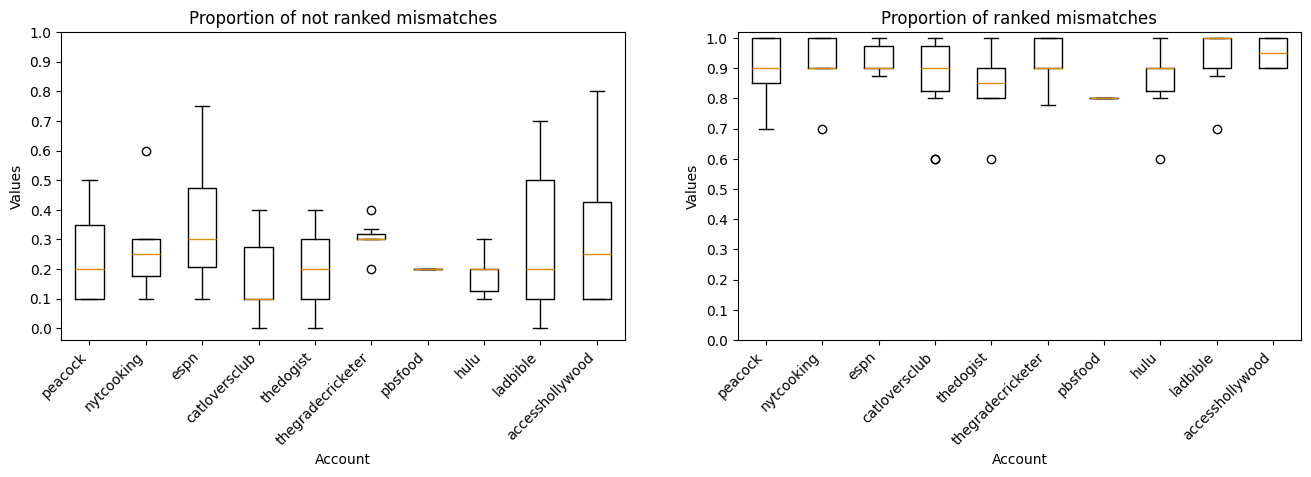

In [7]:
flag = 'nonnews'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

crawl1 = 'chronological'
crawl2 = 'male_dem_ny_1'

temp_df = plot_df.copy()
account_fprops_no_rank, account_fprops_rank, temp_df = compute_fprops(crawl1, crawl2, temp_df, plot_urls)


accounts = list(account_fprops_no_rank.keys())
values_no_rank = [account_fprops_no_rank[acc] for acc in accounts]
values_rank = [account_fprops_rank[acc] for acc in accounts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.boxplot(values_no_rank, tick_labels=accounts)
ax1.set_title("Proportion of not ranked mismatches")
ax1.set_xlabel("Account")
ax1.set_ylabel("Values")
ax1.set_xticks(range(1, 11))
ax1.set_xticklabels(accounts, rotation=45, ha='right')
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax2.boxplot(values_rank, tick_labels=accounts)
ax2.set_title("Proportion of ranked mismatches")
ax2.set_xlabel("Account")
ax2.set_ylabel("Values")
ax2.set_xticks(range(1, 11))
ax2.set_xticklabels(accounts, rotation=45, ha='right')
ax2.set_yticks(np.arange(0, 1.1, 0.1))

plt.show()

division by zero catloversclub DSC60BKkrYV 0 0
division by zero ladbible DSAzKDHjI_T 0 0
division by zero ladbible DSCoNYQDAK- 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero accesshollywood DSDU9GlDmn4 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catl

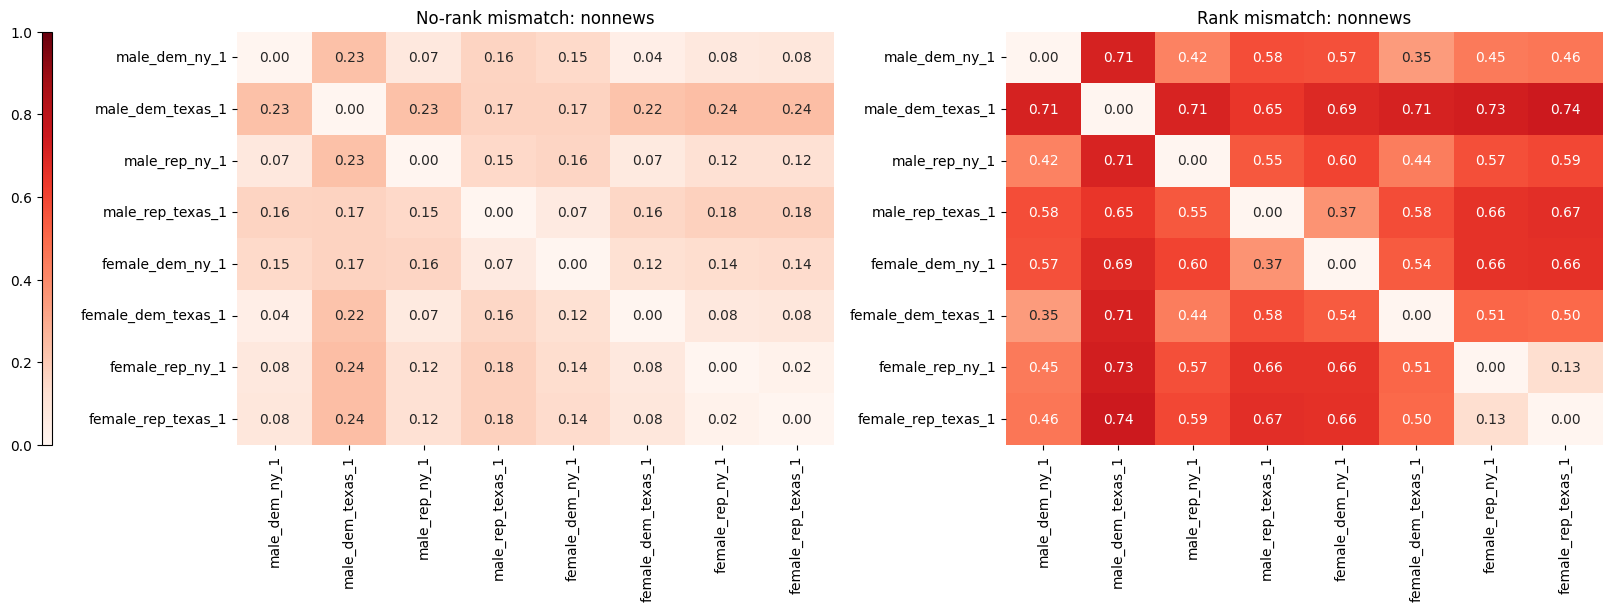

In [11]:
flag = 'nonnews'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

mismatch_no_rank, mismatch_rank = {}, {}

for crawl1 in all_crawls:
    mismatch_no_rank[crawl1] = {}
    mismatch_rank[crawl1] = {}
    for crawl2 in all_crawls:
        mod_df = plot_df.copy()
        _, _, mod_df = compute_fprops(crawl1, crawl2, mod_df, plot_urls)

        temp_df = mod_df[mod_df['comment_num'] == 0]
        mismatch_no_rank[crawl1][crawl2] = temp_df['fcount_no_rank'].sum() / temp_df['ftrials_no_rank'].sum()
        mismatch_rank[crawl1][crawl2] = temp_df['fcount_rank'].sum() / temp_df['ftrials_rank'].sum()

mismatch_rank_df = pd.DataFrame.from_dict(mismatch_rank, orient="index")
mismatch_no_rank_df = pd.DataFrame.from_dict(mismatch_no_rank, orient="index")


fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

hm0 = sns.heatmap(
    mismatch_no_rank_df, annot=True, fmt=".2f",
    cmap="Reds", vmin=0, vmax=1,
    ax=axes[0], cbar=False
)
axes[0].set_title(f"No-rank mismatch: {flag}")

hm1 = sns.heatmap(
    mismatch_rank_df, annot=True, fmt=".2f",
    cmap="Reds", vmin=0, vmax=1,
    ax=axes[1], cbar=False
)
axes[1].set_title(f"Rank mismatch: {flag}")

cbar = fig.colorbar(
    hm0.collections[0],
    ax=axes,
    orientation="vertical",
    location="left", 
    pad=0.02,
    fraction=0.06,
    aspect=40
)
cbar.ax.xaxis.set_ticks_position("top")
cbar.ax.xaxis.set_label_position("top")

plt.show()


### Regression Analysis

In [6]:
nonnews_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_nonnews.csv'

nonnews_df = pd.read_csv(nonnews_filepath)
reg_nonnews_df = get_df_for_regression(nonnews_df, nonnews_urls, all_crawls)
reg_nonnews_df.shape

division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0


(4312, 9)

In [7]:
reg_nonnews_df.drop_duplicates(inplace=True)
reg_nonnews_df.shape

(2089, 9)

In [8]:
reg_nonnews_df.dropna(inplace=True)
reg_nonnews_df.shape

(2089, 9)

In [9]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_NonPolitical_Accounts')
accounts_data.head(3)

reg_nonnews_df = pd.merge(reg_nonnews_df, accounts_data, on='account', how='inner')
reg_nonnews_df.shape

(2089, 12)

In [10]:
with open('/Users/brahmaninutakki/saarland/insta-comments/saved_data/comments_data_nonnews.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_nonnews_df = reg_nonnews_df.merge(comments_df, on='urlid', how='left')
reg_nonnews_df = reg_nonnews_df.merge(likes_df, on='urlid', how='left')

reg_nonnews_df[reg_nonnews_df['comments_count'].isna()]['urlid'].unique()

array(['DSC60BKkrYV'], dtype=object)

In [11]:
reg_nonnews_df = reg_nonnews_df[reg_nonnews_df['urlid'] != 'DSC60BKkrYV']
reg_nonnews_df.shape

(2068, 14)

#### only non-news reg

In [12]:
reg_nonnews_df['fcount_no_rank'] = reg_nonnews_df['fcount_no_rank'].astype(int)
reg_nonnews_df['ftrials_no_rank'] = reg_nonnews_df['ftrials_no_rank'].astype(int)
reg_nonnews_df['fcount_rank'] = reg_nonnews_df['fcount_rank'].astype(int)
reg_nonnews_df['ftrials_rank'] = reg_nonnews_df['ftrials_rank'].astype(int)

(reg_nonnews_df[reg_nonnews_df['fcount_no_rank'] > reg_nonnews_df['ftrials_no_rank']]).shape, (reg_nonnews_df[reg_nonnews_df['fcount_rank'] > reg_nonnews_df['ftrials_rank']]).shape

((0, 14), (0, 14))

In [13]:
reg_nonnews_df['ideology'].value_counts()

ideology
dem_rep    1166
dem_dem     454
rep_rep     448
Name: count, dtype: int64

In [14]:
reg_nonnews_df['gender_diff'] = reg_nonnews_df['gender'].apply(lambda x: 'No' if x in ['female_female', 'male_male'] else 'Yes')
reg_nonnews_df['location_diff'] = reg_nonnews_df['location'].apply(lambda x: 'No' if x in ['ny_ny', 'texas_texas'] else 'Yes')
reg_nonnews_df['ideology_diff'] = reg_nonnews_df['ideology'].apply(lambda x: 'No' if x in ['dem_dem', 'rep_rep'] else 'Yes')

In [27]:
account_topic_map = {'espn': 'Sports',
                     'ladbible': 'Entertainment',
                     'thedogist': 'Pets',
                     'catloversclub': 'Pets',
                     'accesshollywood': 'Entertainment',
                     'nytcooking': 'Food',
                     'thegradecricketer': 'Sports',
                     'peacock': 'Entertainment',
                     'hulu': 'Entertainment',
                     'pbsfood': 'Food'}
reg_nonnews_df['main_topic'] = reg_nonnews_df['account'].apply(lambda x: account_topic_map[x])
reg_nonnews_df['main_topic'].value_counts()

main_topic
Entertainment    843
Pets             511
Sports           470
Food             244
Name: count, dtype: int64

In [25]:
reg_nonnews_df['account'].value_counts()

account
espn                 279
ladbible             274
thedogist            268
catloversclub        243
accesshollywood      218
nytcooking           216
thegradecricketer    191
peacock              189
hulu                 162
pbsfood               28
Name: count, dtype: int64

In [28]:
for col in ["posts", "followers", "following", "comments_count"]:
    new_col = col + "_logz"
    x = np.log1p(reg_nonnews_df[col].astype(float))
    reg_nonnews_df[new_col] = (x - x.mean()) / x.std()

reg_nonnews_df["gender"] = pd.Categorical(
    reg_nonnews_df["gender"],
    categories=["female_female", "male_male", "female_male"],
    ordered=True
)

reg_nonnews_df["ideology"] = pd.Categorical(
    reg_nonnews_df["ideology"],
    categories=["dem_dem", "rep_rep", "dem_rep"],
    ordered=True
)

reg_nonnews_df["location"] = pd.Categorical(
    reg_nonnews_df["location"],
    categories=["ny_ny", "texas_texas", "ny_texas"],
    ordered=True
)

reg_nonnews_df["gender_diff"] = pd.Categorical(
    reg_nonnews_df["gender_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_nonnews_df["ideology_diff"] = pd.Categorical(
    reg_nonnews_df["ideology_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_nonnews_df["location_diff"] = pd.Categorical(
    reg_nonnews_df["location_diff"],
    categories=["No", "Yes"],
    ordered=True
)

reg_nonnews_df['main_topic'] = pd.Categorical(
    reg_nonnews_df['main_topic']
)

In [29]:
reg_nonnews_df.head()

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,posts,followers,following,comments_count,likes_count,gender_diff,location_diff,ideology_diff,posts_logz,followers_logz,following_logz,comments_count_logz,main_topic
0,ny_texas,male_male,dem_dem,DSB-0hjkQNx,accesshollywood,0,20,2,10,28864,1800000,1470,25.0,884.0,No,Yes,No,0.636946,-0.757373,1.043011,-1.288192,Entertainment
1,ny_texas,male_male,dem_dem,DSBAeqRk4is,accesshollywood,10,20,6,10,28864,1800000,1470,846.0,2800.0,No,Yes,No,0.636946,-0.757373,1.043011,1.435437,Entertainment
2,ny_texas,male_male,dem_dem,DSC5lsdkySq,accesshollywood,4,20,9,10,28864,1800000,1470,49.0,1900.0,No,Yes,No,0.636946,-0.757373,1.043011,-0.776925,Entertainment
3,ny_texas,male_male,dem_dem,DSD1KHYkXtU,accesshollywood,2,20,3,10,28864,1800000,1470,19.0,2800.0,No,Yes,No,0.636946,-0.757373,1.043011,-1.493319,Entertainment
4,ny_texas,male_male,dem_dem,DSDKXfBCjPl,accesshollywood,10,20,9,10,28864,1800000,1470,133.0,2200.0,No,Yes,No,0.636946,-0.757373,1.043011,-0.006171,Entertainment


In [35]:
formula = "fcount_no_rank ~ gender_diff + location_diff + ideology_diff + comments_count_logz + C(main_topic)" 
get_vif(formula, reg_nonnews_df)

,feature,VIF
1,gender_diff[T.Yes],1.076140
3,ideology_diff[T.Yes],1.078820
2,location_diff[T.Yes],1.079744
4,C(main_topic)[T.Food],1.153765
7,comments_count_logz,1.158534
5,C(main_topic)[T.Pets],1.257643
6,C(main_topic)[T.Sports],1.314115
0,Intercept,8.505776


In [37]:
reg_nonnews_df['main_topic'].value_counts()

main_topic
Entertainment    843
Pets             511
Sports           470
Food             244
Name: count, dtype: int64

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [kappa, Intercept, location_diff, gender_diff, ideology_diff, comments_count_logz, main_topic, 1|urlid_sigma, 1|urlid_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 47 seconds.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
kappa,8.217,0.499,7.298,9.186,0.005,0.006,9953.0,5790.0,1.0
Intercept,-1.829,0.157,-2.134,-1.543,0.005,0.002,1150.0,2256.0,1.0
location_diff[Yes],-0.160,0.050,-0.250,-0.065,0.000,0.001,13724.0,6257.0,1.0
gender_diff[Yes],0.081,0.051,-0.018,0.174,0.000,0.001,12418.0,5978.0,1.0
ideology_diff[Yes],-0.065,0.050,-0.160,0.027,0.001,0.001,9897.0,5633.0,1.0
...,...,...,...,...,...,...,...,...,...
1|urlid[DSERcMKEs-k],-0.471,0.278,-0.970,0.069,0.006,0.003,2152.0,3814.0,1.0
1|urlid[DSEVBjZAOdU],-0.851,0.299,-1.396,-0.275,0.007,0.004,1613.0,2992.0,1.0
1|urlid[DSEWMX5jGnh],0.044,0.278,-0.482,0.566,0.007,0.003,1577.0,3264.0,1.0
1|urlid[DSEgVgeAPWE],0.157,0.266,-0.338,0.671,0.007,0.003,1630.0,3353.0,1.0


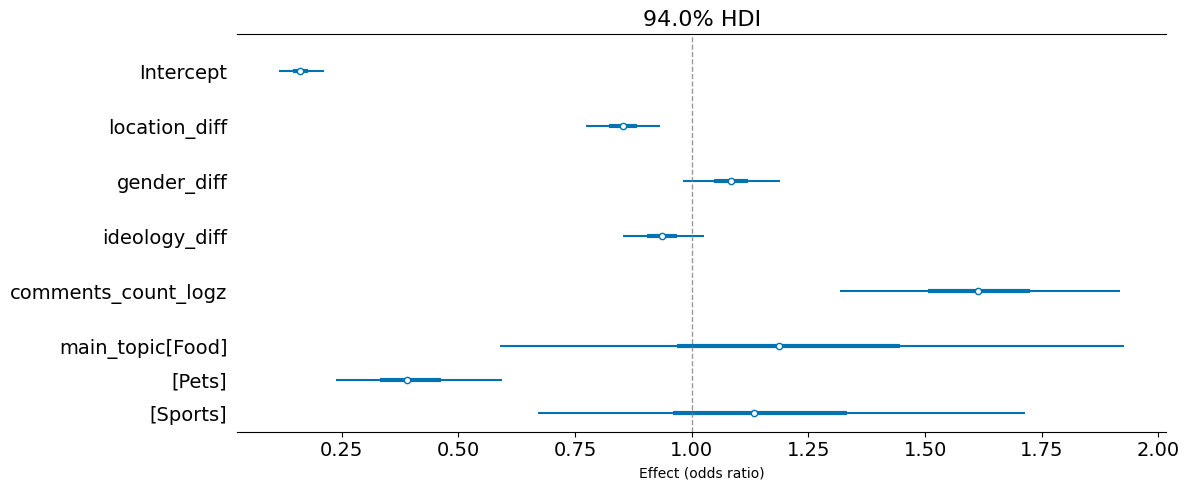

In [38]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location_diff + gender_diff + ideology_diff + comments_count_logz + main_topic + (1|urlid)",
    data=reg_nonnews_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.95,
    chains=4,
    cores=4,
    # random_seed=42,
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names = ['Intercept', 'location_diff', 'gender_diff', 'ideology_diff', 'comments_count_logz', 'main_topic']
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

In [39]:
formula = "fcount_no_rank ~ C(location) + C(gender) + C(ideology) + posts_logz + followers_logz + following_logz + comments_count_logz + C(main_topic)" 
formula = "fcount_no_rank ~ C(location) + C(gender) + C(ideology) + comments_count_logz + C(main_topic)" 
get_vif(formula, reg_nonnews_df)

,feature,VIF
7,C(main_topic)[T.Food],1.153771
10,comments_count_logz,1.158568
8,C(main_topic)[T.Pets],1.257656
9,C(main_topic)[T.Sports],1.314180
5,C(ideology)[T.rep_rep],1.556468
1,C(location)[T.texas_texas],1.566160
3,C(gender)[T.male_male],1.580746
6,C(ideology)[T.dem_rep],1.637260
2,C(location)[T.ny_texas],1.644865
4,C(gender)[T.female_male],1.653304


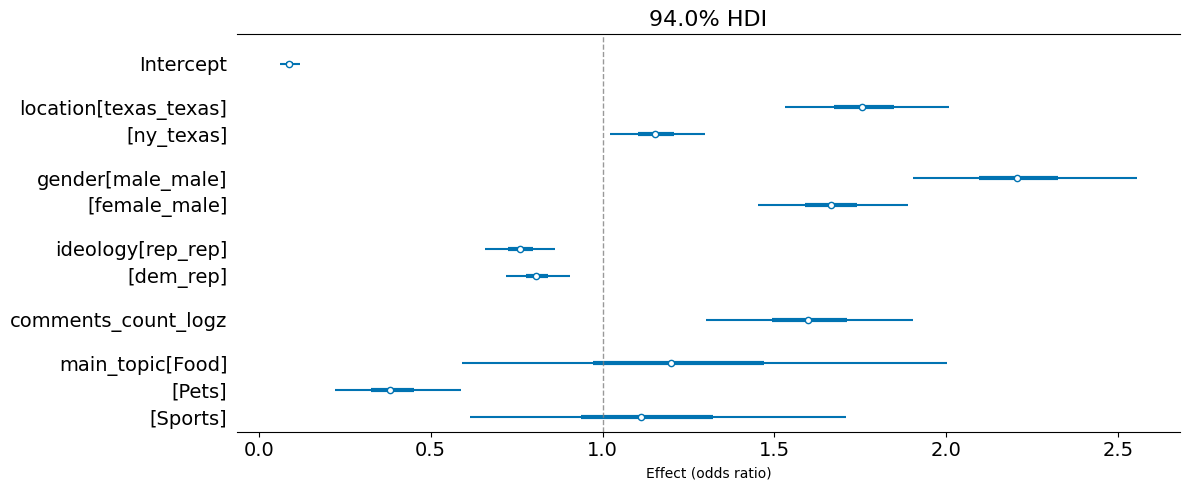

In [41]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology + comments_count_logz + main_topic + (1|urlid)",
    data=reg_nonnews_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.95,
    chains=4,
    cores=4,
    # random_seed=42,
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(12, 5),
    r_hat=False,
    ess=False,
    var_names = ['Intercept', 'location', 'gender', 'ideology', 'comments_count_logz', 'main_topic']
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()